# GNN for IoMT Attack Detection

This notebook implements a Graph Neural Network (GNN) to detect cyber attacks (Spoofing and Data Alteration) using the WUSTL-EHMS-2020 dataset.

## Step 1: Data Preprocessing
First, we import the necessary libraries.

In [31]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# For graph operations
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity

print('Libraries imported successfully!')

Libraries imported successfully!


### Load Data and Clean Columns
We load the dataset and drop columns that are not useful for prediction (like MAC addresses and IP addresses since there is only 1 pair). We also drop port numbers (`Sport` and `Dport`) because their numerical magnitudes are not meaningful features for scaling, and they contain mixed string types.

In [32]:
# Load the dataset
df = pd.read_csv('wustl-ehms-2020_with_attacks_categories.csv')

# Drop columns that are identifiers, constant, or categorical ports
drop_cols = ['Dir', 'SrcAddr', 'DstAddr', 'SrcMac', 'DstMac', 'Sport', 'Dport']
df = df.drop(columns=drop_cols)

print(f'Dataset loaded. Shape: {df.shape}')
print(f"\nAttack categories:\n{df['Attack Category'].value_counts()}")

Dataset loaded. Shape: (16318, 38)

Attack categories:
Attack Category
normal             14272
Spoofing            1124
Data Alteration      922
Name: count, dtype: int64


### Encode Categoricals and Scale Features
We encode the `Flgs` column and the target labels, then scale the numeric features. **Crucially, we exclude `Packet_num` from the feature vector** so it does not interfere with feature similarity, but we keep it around to build the temporal edges later.

In [33]:
# Encode flags
le_flags = LabelEncoder()
df['Flgs_encoded'] = le_flags.fit_transform(df['Flgs'])

# Encode target labels: Normal -> 0, Spoofing -> 1, Data Alteration -> 2
label_mapping = {'normal': 0, 'Spoofing': 1, 'Data Alteration': 2}
y = df['Attack Category'].map(label_mapping).values

# Define the features we will use for the GNN nodes
# We exclude 'Flgs' (original string), 'Attack Category', 'Label' (binary label), and 'Packet_num'
exclude_for_scaling = ['Flgs', 'Attack Category', 'Label', 'Packet_num']
feature_cols = [col for col in df.columns if col not in exclude_for_scaling]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_cols])

print(f'Feature matrix shape: {X_scaled.shape}')
print(f'Target vector shape: {y.shape}')

Feature matrix shape: (16318, 35)
Target vector shape: (16318,)


### Create Train / Validation / Test Masks
GNNs train on a single large graph, so instead of physically splitting the data, we use boolean masks to hide labels during training.

In [34]:
# Generate indices for the split (70% train, 15% val, 15% test)
indices = np.arange(len(df))
idx_train, idx_temp, y_train, y_temp = train_test_split(indices, y, test_size=0.3, stratify=y, random_state=42)
idx_val, idx_test, y_val, y_test = train_test_split(idx_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# Create boolean masks
train_mask = torch.zeros(len(df), dtype=torch.bool)
val_mask = torch.zeros(len(df), dtype=torch.bool)
test_mask = torch.zeros(len(df), dtype=torch.bool)

train_mask[idx_train] = True
val_mask[idx_val] = True
test_mask[idx_test] = True

print(f'Train nodes: {train_mask.sum().item()}')
print(f'Val nodes: {val_mask.sum().item()}')
print(f'Test nodes: {test_mask.sum().item()}')

Train nodes: 11422
Val nodes: 2448
Test nodes: 2448


### Construct the Graph using PyTorch Geometric
We construct the graph using `torch_geometric.data.Data`. The graph will contain two types of edges:
1. **Temporal Edges**: Connecting consecutive packets.
2. **Feature Similarity Edges**: Using K-Nearest Neighbors (KNN) to connect packets with similar characteristics.

In [35]:
import torch
import torch._utils


import torch_geometric

from torch_geometric.data import Data
from sklearn.neighbors import NearestNeighbors

# 1. Node Features and Labels
x = torch.tensor(X_scaled, dtype=torch.float)
y_tensor = torch.tensor(y, dtype=torch.long)

# 2. Build Temporal Edges (Connecting i to i+1)
# Assuming the data is sequentially captured, we create edges between consecutive rows
num_nodes = len(df)
source_nodes = np.arange(num_nodes - 1)
target_nodes = np.arange(1, num_nodes)

temporal_edge_index = np.vstack((source_nodes, target_nodes))
# Add reverse edges to make it undirected
temporal_edge_index = np.concatenate([temporal_edge_index, temporal_edge_index[::-1]], axis=1)

# 3. Build Feature Similarity Edges (K-Nearest Neighbors)
print("Computing KNN edges...")
k = 5
knn = NearestNeighbors(n_neighbors=k+1, metric='cosine', n_jobs=-1)
knn.fit(X_scaled)
distances, indices = knn.kneighbors(X_scaled)

# Create edge pairs from KNN (ignoring the first neighbor which is the node itself)
knn_sources = np.repeat(np.arange(num_nodes), k)
knn_targets = indices[:, 1:].flatten()

knn_edge_index = np.vstack((knn_sources, knn_targets))
# Add reverse edges for undirected graph
knn_edge_index = np.concatenate([knn_edge_index, knn_edge_index[::-1]], axis=1)

# 4. Combine all edges
combined_edges = np.concatenate([temporal_edge_index, knn_edge_index], axis=1)
# Remove duplicate edges
edge_index_unique = np.unique(combined_edges, axis=1)

edge_index_tensor = torch.tensor(edge_index_unique, dtype=torch.long)

# 5. Create PyTorch Geometric Data Object
data = Data(x=x, edge_index=edge_index_tensor, y=y_tensor)

# Add our masks to the data object
data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask

print(f"Graph constructed successfully!")
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.num_edges}")
print(f"Number of features: {data.num_features}")
print(f"Number of classes: {len(np.unique(y))}")



Computing KNN edges...


Graph constructed successfully!
Number of nodes: 16318
Number of edges: 128196
Number of features: 35
Number of classes: 3


Converting PyTorch Geometric data to NetworkX...
Computing layout, this may take a while for large graphs...
Drawing the graph...


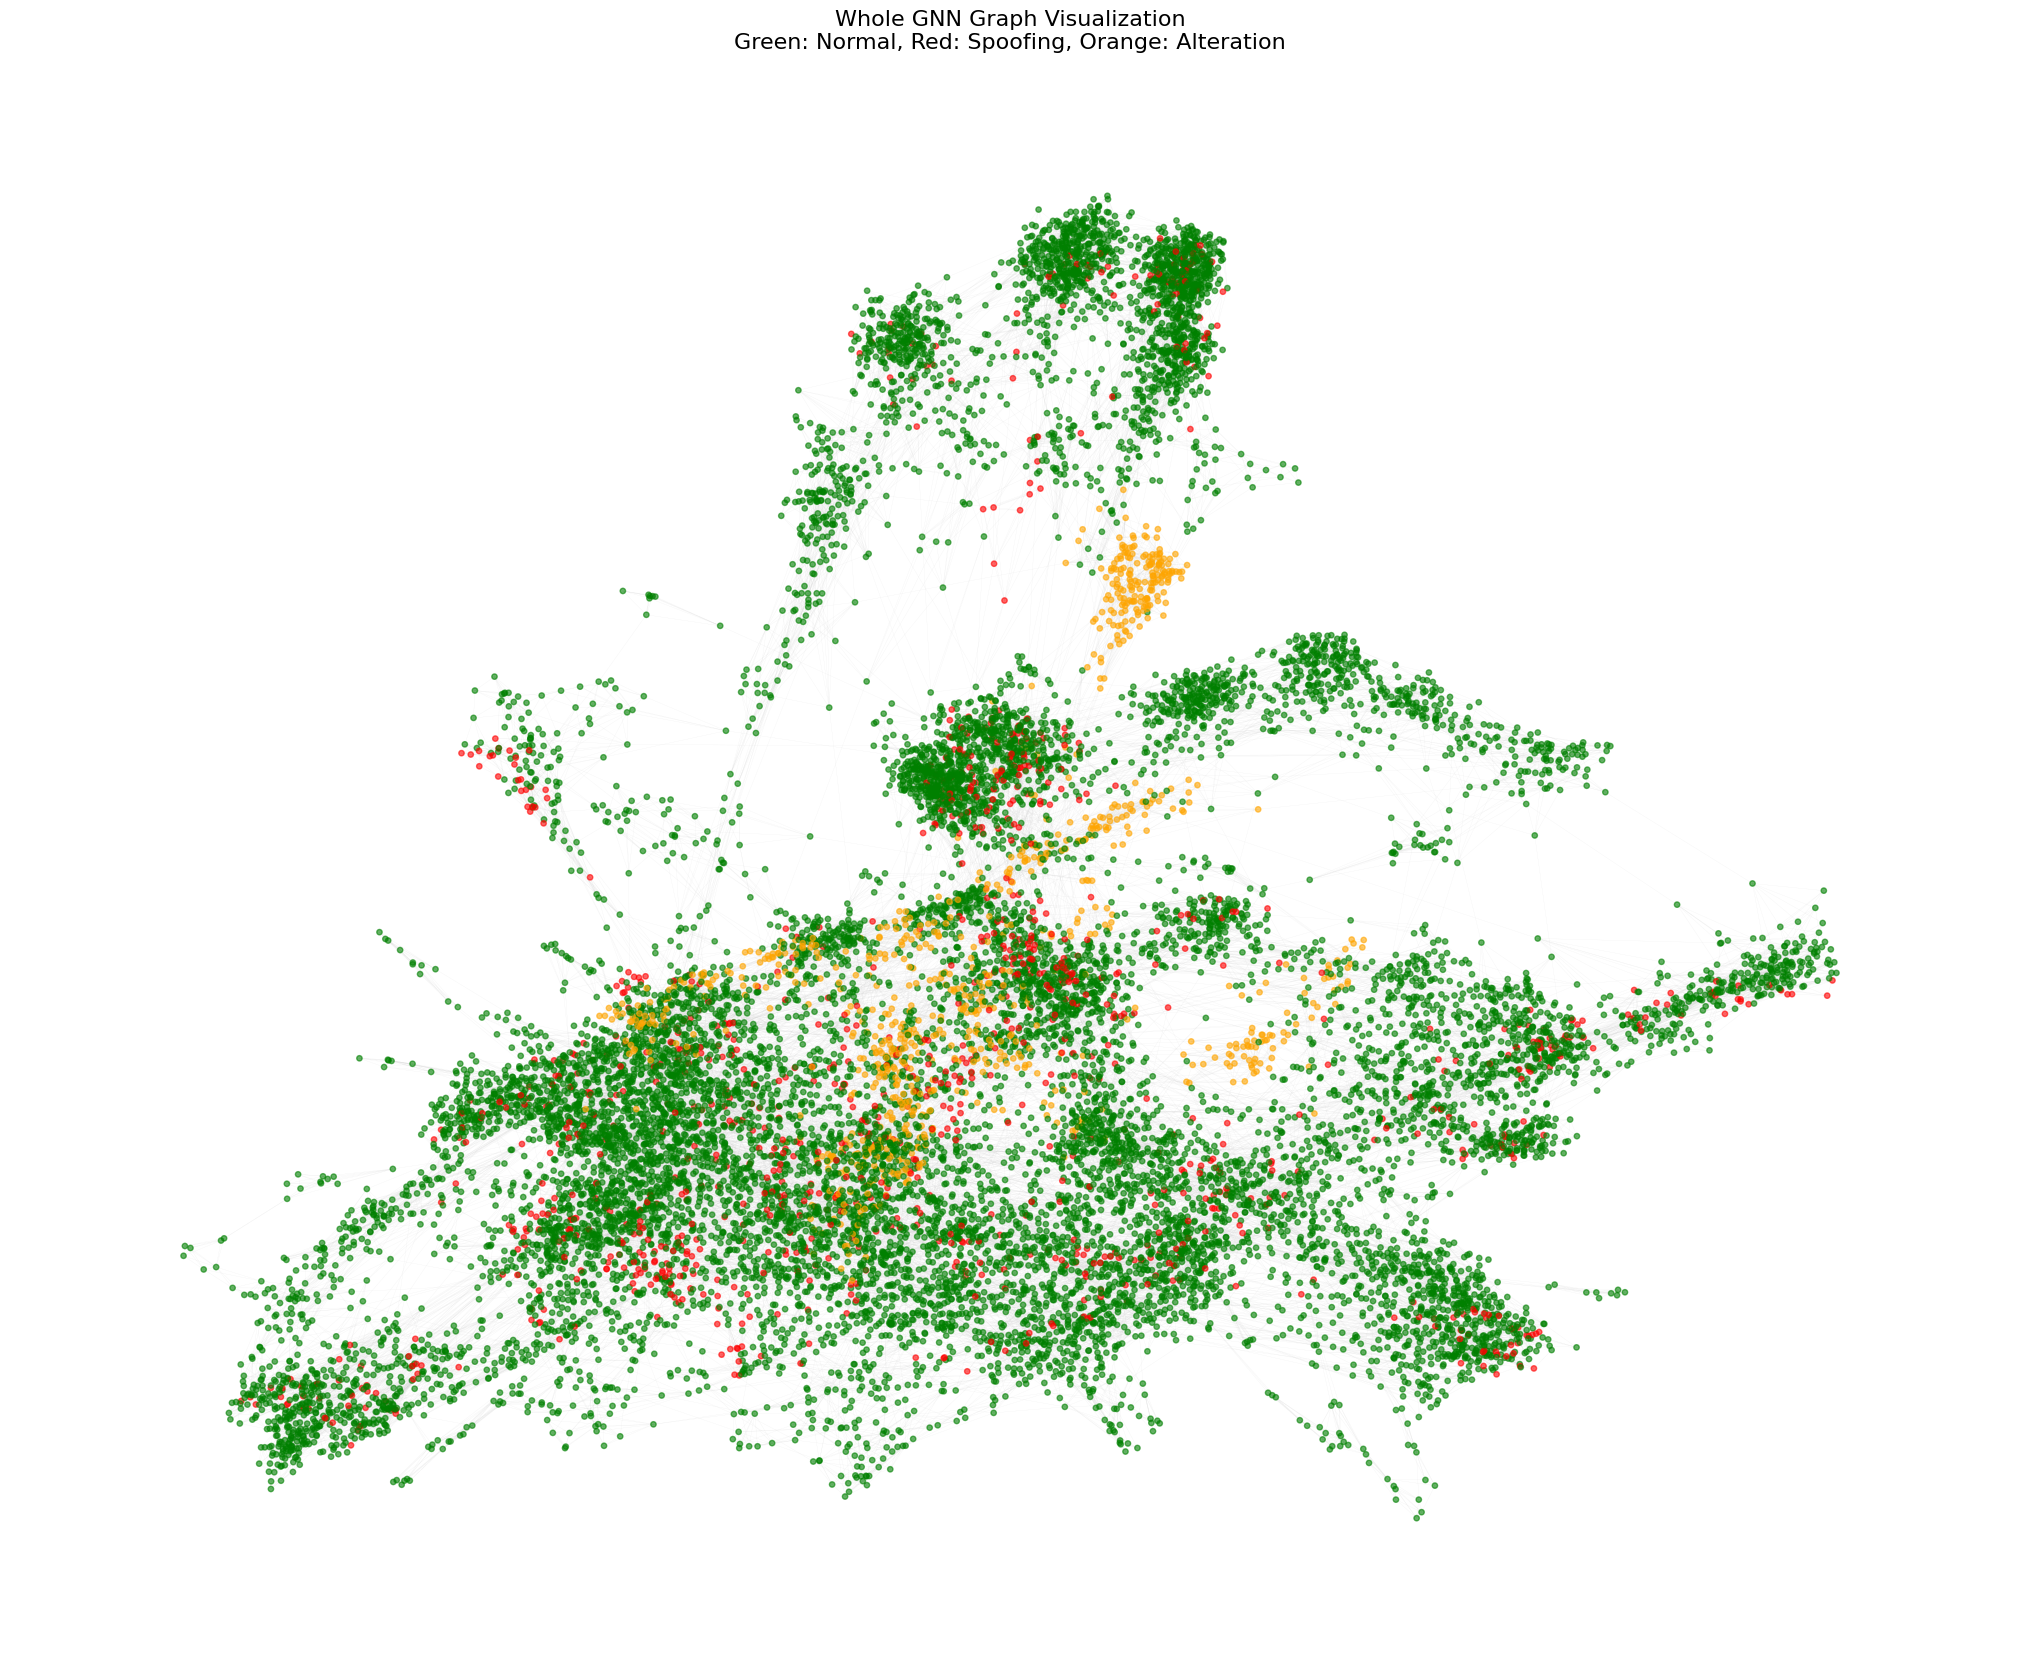

Visualization complete!


In [36]:
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx

# 1. Convert the entire PyTorch Geometric Data object to a NetworkX graph
print("Converting PyTorch Geometric data to NetworkX...")
G = to_networkx(data, to_undirected=True)

# 2. Assign colors based on the attack category (Label)
# 0: Normal (Green), 1: Spoofing (Red), 2: Data Alteration (Orange)
color_map = []
for node in G.nodes():
    label = data.y[node].item()
    if label == 0:
        color_map.append('green')
    elif label == 1:
        color_map.append('red')
    else:
        color_map.append('orange')

# 3. Draw the graph
plt.figure(figsize=(20, 16)) # Larger figure size for the whole graph

print("Computing layout, this may take a while for large graphs...")
# Calculate node positions (this is the computationally expensive part)
pos = nx.spring_layout(G, seed=42) 

print("Drawing the graph...")
nx.draw(
    G, 
    pos, 
    node_color=color_map, 
    node_size=15,          # Much smaller nodes
    edge_color='lightgray', 
    width=0.1,             # Thinner edges
    with_labels=False, 
    alpha=0.6              # Slight transparency
)

plt.title("Whole GNN Graph Visualization\nGreen: Normal, Red: Spoofing, Orange: Alteration", fontsize=16)
plt.show()
print("Visualization complete!")


Small Index based SUBGRAPH

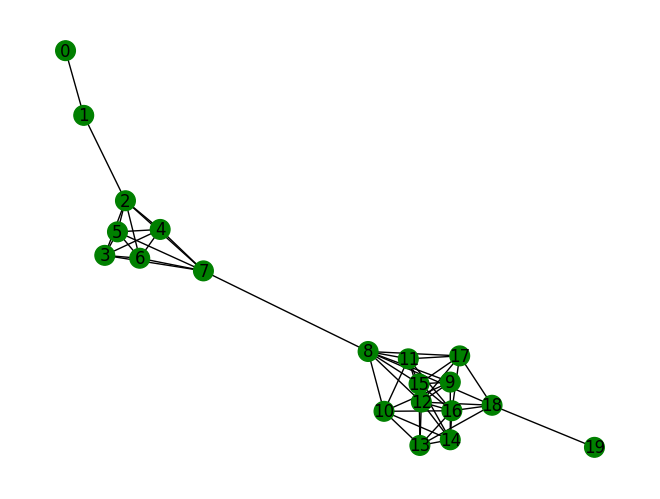

In [37]:
sub_nodes = list(range(20))   # first 20 nodes
H = G.subgraph(sub_nodes)

pos = nx.spring_layout(H, seed=42)

nx.draw(
    H, pos,
    node_color=[color_map[i] for i in sub_nodes],
    with_labels=True,
    node_size=200
)


plt.show()

In [38]:
# Show the first 20 rows of the dataset to manually verify the plot
display(df.iloc[0:20][['Attack Category', 'TotPkts', 'TotBytes', 'Flgs']])


,Attack Category,TotPkts,TotBytes,Flgs
0,normal,7,682,e
1,normal,7,682,e
2,normal,7,682,e
3,normal,7,682,e
4,normal,7,682,e
5,normal,7,682,e
6,normal,7,682,e
7,normal,7,682,e
8,normal,7,682,e
9,normal,7,682,e


Targeting Spoofing Attack at Row Index: 249


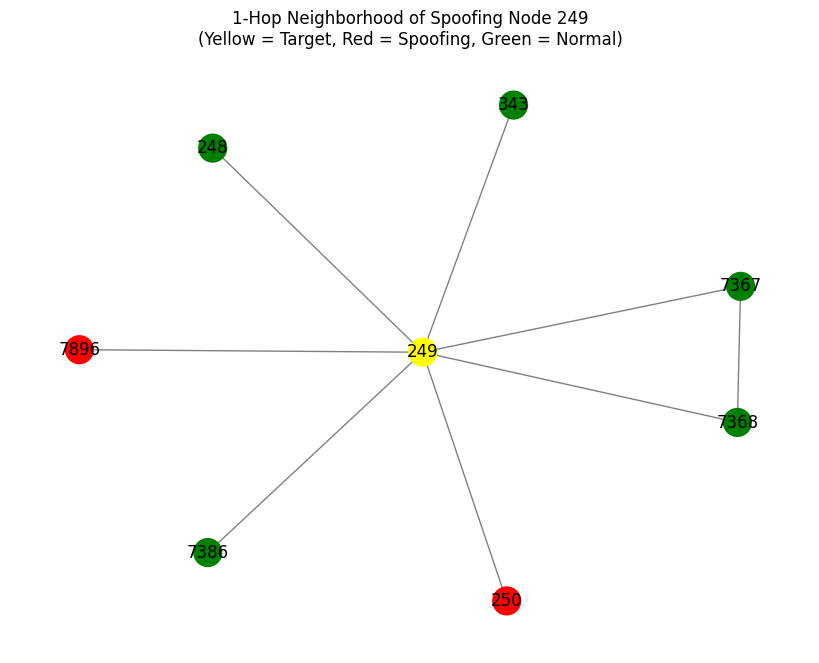


--- Manual Verification Data ---


,Attack Category,TotPkts,TotBytes,Flgs
248,normal,7,682,e
249,Spoofing,7,682,eR
250,Spoofing,7,682,eR
343,normal,7,682,e
7367,normal,7,682,e
7368,normal,7,682,e
7386,normal,7,682,e
7896,Spoofing,7,682,eR


In [39]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Find the index of the first 'Spoofing' attack (or 'Data Alteration')
# attack_category label: 0 is Normal, 1 is Spoofing, 2 is Data Alteration
spoofing_indices = df[df['Attack Category'] == 'Spoofing'].index

# Let's pick the first spoofing node we find
target_node = spoofing_indices[0] 
print(f"Targeting Spoofing Attack at Row Index: {target_node}")

# 2. Extract the "Ego Graph" (The target node + its direct neighbors up to radius 1)
# radius=1 means 1 hop away (direct connections). radius=2 means neighbors of neighbors.
H_ego = nx.ego_graph(G, target_node, radius=1)

# 3. Plot the Ego Graph
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(H_ego, seed=42)

# Color them: target node is Yellow so it stands out, others keep their standard colors
colors = []
for node in H_ego.nodes():
    if node == target_node:
        colors.append('yellow') # Highlight our target attack node
    else:
        colors.append(color_map[node]) # Normal=Green, Spoofing=Red, Alteration=Orange

nx.draw(
    H_ego, pos,
    node_color=colors,
    with_labels=True,
    node_size=400,
    edge_color='gray'
)
plt.title(f"1-Hop Neighborhood of Spoofing Node {target_node}\n(Yellow = Target, Red = Spoofing, Green = Normal)")
plt.show()

# 4. Display the data to verify MANUALLY
print("\n--- Manual Verification Data ---")
# Get the list of nodes that are in this subgraph, sorted for easy reading
neighbor_nodes = sorted(list(H_ego.nodes()))

# Display these exact rows from the dataset
display_cols = ['Attack Category', 'TotPkts', 'TotBytes', 'Flgs'] # Add any other columns you scaled
display(df.iloc[neighbor_nodes][display_cols])


In [40]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display

# 1. Define target node
target_node = 249
top_k = 15

# 2. Calculate cosine similarities
sims = cosine_similarity(X_scaled[[target_node]], X_scaled)[0]

# 3. Get top 15 indices (excluding the target node itself)
top_indices = np.argsort(sims)[::-1][1:top_k+1]

# 4. Build a new DataFrame with the results
results = []
for idx in top_indices:
    row_data = df.iloc[idx].copy()
    # Add our calculated similarity and keep track of the original row number
    row_data['Similarity Score'] = sims[idx]
    row_data['Original Node'] = idx
    results.append(row_data)

df_similar = pd.DataFrame(results)

# 5. Reorder columns so the most important ones are on the left
main_cols = ['Original Node', 'Similarity Score', 'Attack Category', 'TotPkts', 'TotBytes', 'SrcLoad', 'DstLoad']
other_cols = [c for c in df_similar.columns if c not in main_cols]
df_similar = df_similar[main_cols + other_cols]

# 6. Apply visual styling to the Pandas DataFrame
def highlight_attacks(val):
    if val == 'Spoofing':
        return 'background-color: lightcoral; color: black'
    elif val == 'Data Alteration':
        return 'background-color: orange; color: black'
    elif val == 'normal':
        return 'background-color: lightgreen; color: black'
    return ''

# Format similarity score to 4 decimal places and add background colors
styled_df = (df_similar.style
             .map(highlight_attacks, subset=['Attack Category'])
             .format({'Similarity Score': '{:.4f}'})
             .background_gradient(subset=['Similarity Score'], cmap='Blues'))

# Show the table!
print(f"Top {top_k} nodes mathematically most similar to Node {target_node} (Spoofing):")
display(styled_df)


Top 15 nodes mathematically most similar to Node 249 (Spoofing):


,Original Node,Similarity Score,Attack Category,TotPkts,TotBytes,SrcLoad,DstLoad,Flgs,SrcBytes,DstBytes,SrcGap,DstGap,SIntPkt,DIntPkt,SIntPktAct,DIntPktAct,SrcJitter,DstJitter,sMaxPktSz,dMaxPktSz,sMinPktSz,dMinPktSz,Dur,Trans,Load,Loss,pLoss,pSrcLoss,pDstLoss,Rate,Packet_num,Temp,SpO2,Pulse_Rate,SYS,DIA,Heart_rate,Resp_Rate,ST,Label,Flgs_encoded
7896,7896,0.9082,Spoofing,7,682,11709.000000,3903.000000,eR,496,186,0,0,84.722336,34.781000,0.000000,0,70.823203,34.753000,310,66,60,60,0.254167,1,15612.000000,0,0.000000,0.000000,0.000000,23.607000,7893,27.600000,98,75,142,72,76,30,0.180000,1,6
343,343,0.8360,normal,7,682,29466.000000,9822.000000,e,496,186,0,0,33.666332,47.796000,0.000000,0,43.813168,47.762000,310,66,60,60,0.100999,1,39288.000000,0,0.000000,0.000000,0.000000,59.407000,344,27.500000,98,88,138,78,76,20,0.100000,0,4
7368,7368,0.8345,normal,7,682,56626.000000,18875.000000,e,496,186,0,0,17.518334,1.736000,0.000000,0,22.368951,1.730000,310,66,60,60,0.052555,1,75502.000000,0,0.000000,0.000000,0.000000,114.166000,7365,27.400000,98,76,134,79,76,24,0.180000,0,4
7367,7367,0.8328,normal,7,682,56016.000000,18672.000000,e,496,186,0,0,17.709334,2.356500,0.000000,0,21.822914,2.320500,310,66,60,60,0.053128,1,74688.000000,0,0.000000,0.000000,0.000000,112.935000,7364,27.400000,98,75,134,79,76,24,0.180000,0,4
7386,7386,0.8301,normal,7,682,57233.000000,19078.000000,e,496,186,0,0,17.332666,12.830000,0.000000,0,11.467283,12.776000,310,66,60,60,0.051998,1,76311.000000,0,0.000000,0.000000,0.000000,115.389000,7383,27.400000,97,77,134,79,79,17,0.180000,0,4
7596,7596,0.8288,normal,7,682,49650.000000,16550.000000,e,496,186,0,0,19.980000,2.675000,0.000000,0,24.678150,2.580000,310,66,60,60,0.059940,1,66200.000000,0,0.000000,0.000000,0.000000,100.100000,7593,27.700000,98,78,142,72,71,19,0.140000,0,4
345,345,0.8288,normal,7,682,30595.000000,10198.000000,e,496,186,0,0,32.423334,2.012500,0.000000,0,42.978520,1.978500,310,66,60,60,0.097270,1,40794.000000,0,0.000000,0.000000,0.000000,61.684000,346,27.500000,98,86,138,78,76,20,0.100000,0,4
7385,7385,0.8278,normal,7,682,55459.000000,18486.000000,e,496,186,0,0,17.887000,2.277000,0.000000,0,22.232055,2.242000,310,66,60,60,0.053661,1,73946.000000,0,0.000000,0.000000,0.000000,111.813000,7382,27.400000,97,77,134,79,76,17,0.180000,0,4
7380,7380,0.8277,normal,7,682,54884.000000,18295.000000,e,496,186,0,0,18.074334,13.637500,0.000000,0,10.074152,13.530500,310,66,60,60,0.054223,1,73179.000000,0,0.000000,0.000000,0.000000,110.654000,7377,27.400000,97,74,134,79,72,17,0.180000,0,4
7826,7826,0.8247,normal,7,682,54458.000000,18153.000000,e,496,186,0,0,18.216000,13.830500,0.000000,0,10.943195,13.813500,310,66,60,60,0.054648,1,72610.000000,0,0.000000,0.000000,0.000000,109.794000,7823,27.700000,98,75,142,72,72,15,0.180000,0,4


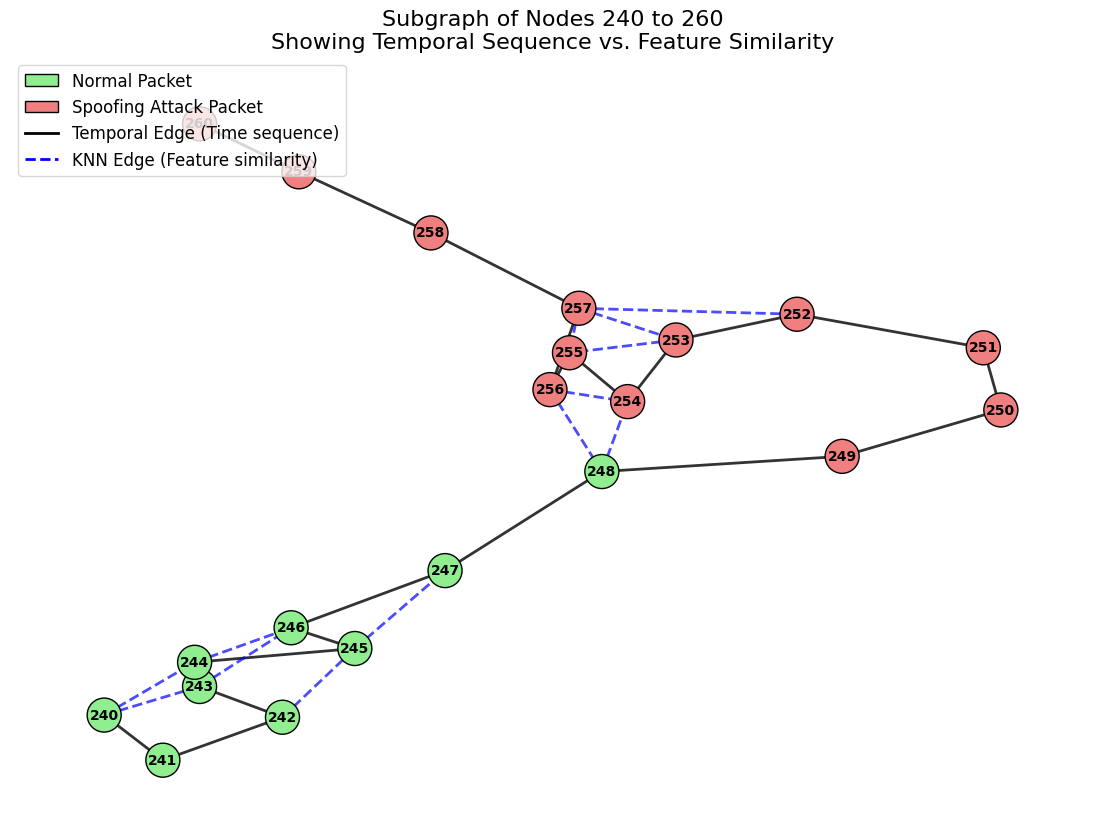

In [41]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# 1. Define the subgraph region (e.g., surrounding the spoofing attack at 249)
start_node = 240
end_node = 260
sub_nodes = list(range(start_node, end_node + 1))

# 2. Extract the subgraph from the master graph G (this DOES NOT alter G)
H = G.subgraph(sub_nodes)

# 3. Categorize the edges that exist in this subgraph
temporal_edges = []
knn_edges = []

for u, v in H.edges():
    # If the nodes are exactly 1 index apart, it's a Temporal (Sequential) edge
    if abs(u - v) == 1:
        temporal_edges.append((u, v))
    else:
        # Otherwise, the algorithm connected them due to Feature Similarity (KNN)
        knn_edges.append((u, v))

# 4. Set up the plot layout
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(H, seed=42)

# Define node colors based on the dataframe
node_colors = []
for node in H.nodes():
    cat = df.iloc[node]['Attack Category']
    if cat == 'normal':
        node_colors.append('lightgreen')
    elif cat == 'Spoofing':
        node_colors.append('lightcoral')
    else:
        node_colors.append('orange')

# --- DRAW THE GRAPH IN LAYERS ---

# Draw Nodes
nx.draw_networkx_nodes(H, pos, node_color=node_colors, node_size=600, edgecolors='black')
nx.draw_networkx_labels(H, pos, font_size=10, font_weight='bold')

# Draw Temporal Edges (Solid Black Lines)
nx.draw_networkx_edges(H, pos, edgelist=temporal_edges, 
                       edge_color='black', style='solid', width=2.0, alpha=0.8)

# Draw KNN Feature Edges (Dashed Blue Lines)
nx.draw_networkx_edges(H, pos, edgelist=knn_edges, 
                       edge_color='blue', style='dashed', width=2.0, alpha=0.7)

# 5. Add a Legend to explain the edges and nodes
legend_elements = [
    Patch(facecolor='lightgreen', edgecolor='black', label='Normal Packet'),
    Patch(facecolor='lightcoral', edgecolor='black', label='Spoofing Attack Packet'),
    Line2D([0], [0], color='black', lw=2, linestyle='solid', label='Temporal Edge (Time sequence)'),
    Line2D([0], [0], color='blue', lw=2, linestyle='dashed', label='KNN Edge (Feature similarity)')
]

plt.legend(handles=legend_elements, loc='upper left', fontsize=12)
plt.title(f"Subgraph of Nodes {start_node} to {end_node}\nShowing Temporal Sequence vs. Feature Similarity", fontsize=16)
plt.axis('off') # Hide the axis grid
plt.show()


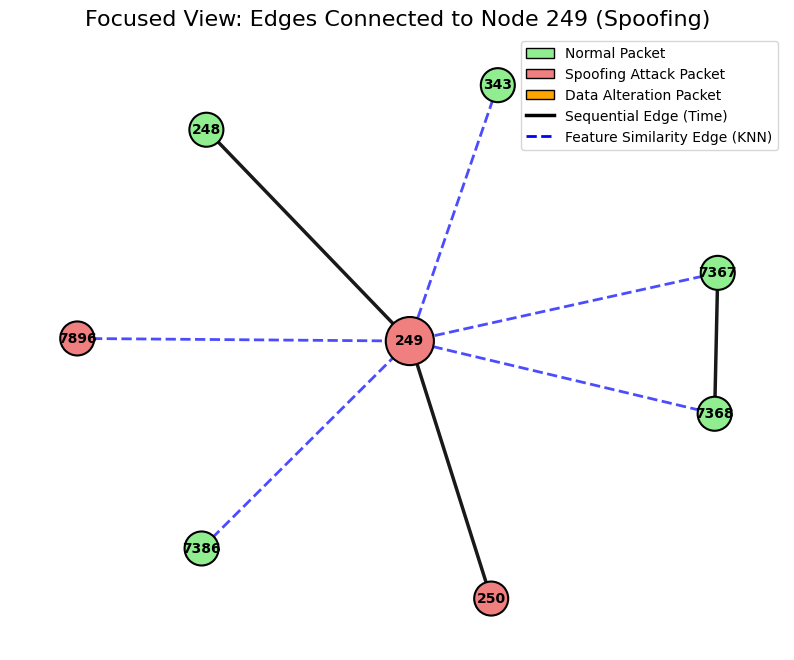

In [42]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

target_node = 249

# 1. Extract the Ego Graph (Node 249 and everything directly connected to it)
# This will automatically grab both its Temporal neighbors and its KNN neighbors
H = nx.ego_graph(G, target_node, radius=1)

# 2. Categorize the edges
temporal_edges = []
knn_edges = []

for u, v in H.edges():
    # If the nodes are exactly 1 index apart, it's a Sequential (Temporal) edge
    if abs(u - v) == 1:
        temporal_edges.append((u, v))
    else:
        # Otherwise, it's a Feature Similarity (KNN) edge
        knn_edges.append((u, v))

# 3. Set up the plot
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(H, seed=42)

# Make the target node stand out by making it larger
node_sizes = []
node_colors = []

for node in H.nodes():
    # Set Size: Make Node 249 larger than the others
    if node == target_node:
        node_sizes.append(1200) 
    else:
        node_sizes.append(600)
        
    # Set Color based on Attack Category
    cat = df.iloc[node]['Attack Category']
    if cat == 'normal':
        node_colors.append('lightgreen')
    elif cat == 'Spoofing':
        node_colors.append('lightcoral')
    else:
        node_colors.append('orange')

# --- DRAW THE GRAPH ---
nx.draw_networkx_nodes(H, pos, node_color=node_colors, node_size=node_sizes, edgecolors='black', linewidths=1.5)
nx.draw_networkx_labels(H, pos, font_size=10, font_weight='bold')

# Draw Sequential/Temporal Edges (Solid Black Lines)
nx.draw_networkx_edges(H, pos, edgelist=temporal_edges, 
                       edge_color='black', style='solid', width=2.5, alpha=0.9)

# Draw Feature Similarity/KNN Edges (Dashed Blue Lines)
nx.draw_networkx_edges(H, pos, edgelist=knn_edges, 
                       edge_color='blue', style='dashed', width=2.0, alpha=0.7)

# 4. Add Legend
legend_elements = [
    Patch(facecolor='lightgreen', edgecolor='black', label='Normal Packet'),
    Patch(facecolor='lightcoral', edgecolor='black', label='Spoofing Attack Packet'),
    Patch(facecolor='orange', edgecolor='black', label='Data Alteration Packet'),
    Line2D([0], [0], color='black', lw=2.5, linestyle='solid', label='Sequential Edge (Time)'),
    Line2D([0], [0], color='blue', lw=2.0, linestyle='dashed', label='Feature Similarity Edge (KNN)')
]

plt.legend(handles=legend_elements, loc='best')
plt.title(f"Focused View: Edges Connected to Node {target_node} (Spoofing)", fontsize=16)
plt.axis('off')
plt.show()


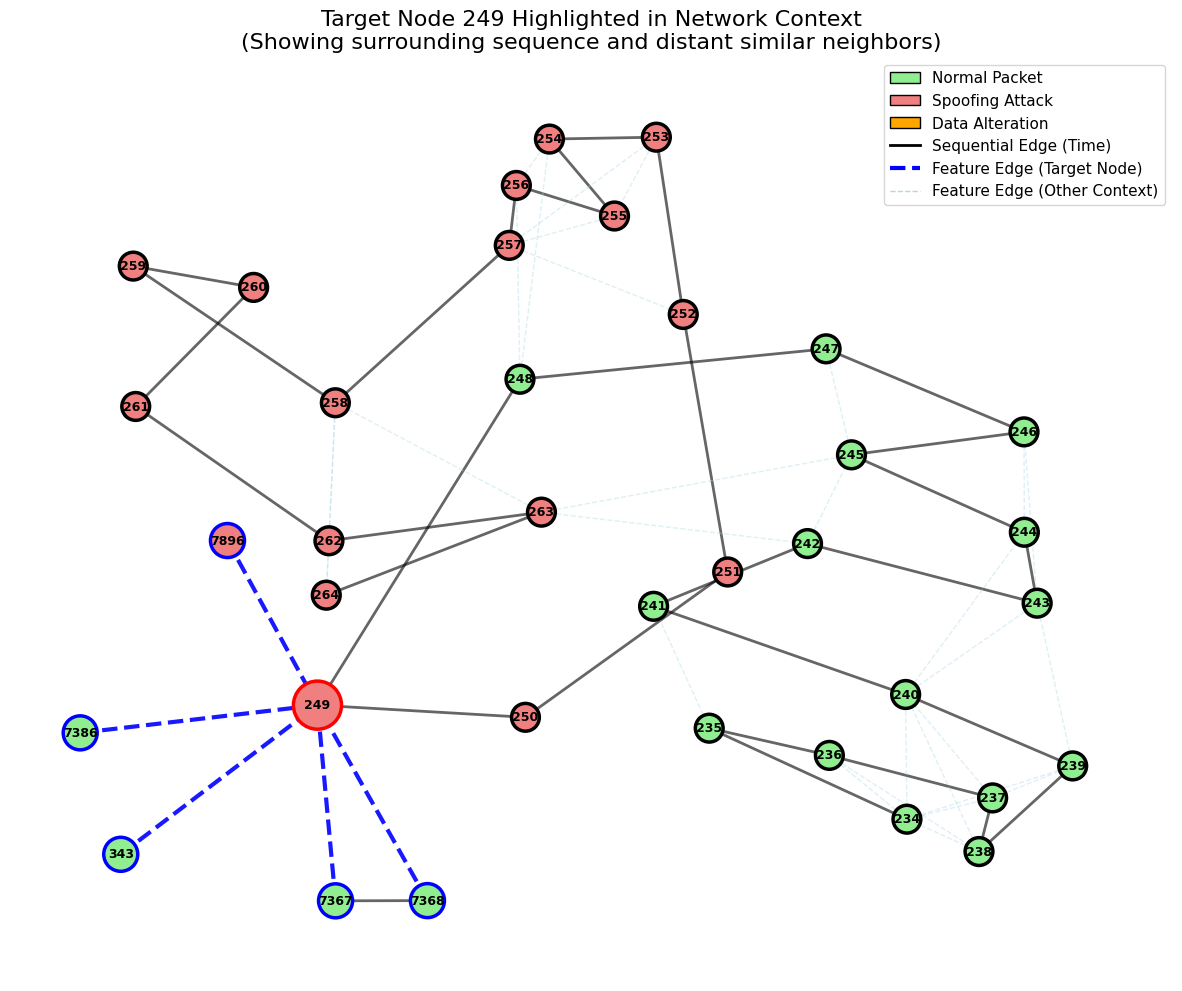

In [43]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

target_node = 249

# 1. Get the context sequence (15 nodes before and 15 nodes after)
start_node = target_node - 15
end_node = target_node + 15
context_nodes = list(range(start_node, end_node + 1))

# 2. Get the specific KNN neighbors of the target node so they appear in the plot
# (We filter out the neighbors that are just 1 step away, as those are temporal)
knn_neighbors = [n for n in G.neighbors(target_node) if abs(n - target_node) > 1]

# Combine them to form the nodes of our subgraph
# set() removes any duplicates if they overlap
sub_nodes = list(set(context_nodes + knn_neighbors))

# 3. Extract the larger subgraph
H = G.subgraph(sub_nodes)

# 4. Categorize edges for styling
temporal_edges = []
knn_edges = []

for u, v in H.edges():
    if abs(u - v) == 1:
        temporal_edges.append((u, v))
    else:
        knn_edges.append((u, v))

# 5. Set up the plot
plt.figure(figsize=(15, 12)) # Larger figure to fit the context
pos = nx.spring_layout(H, k=0.5, seed=42) # k adjusts the optimal distance between nodes

# Determine Node Colors, Sizes, and Borders
node_sizes = []
node_colors = []
border_colors = []

for node in H.nodes():
    # Size and Border
    if node == target_node:
        node_sizes.append(1200)      # Target node is biggest
        border_colors.append('red')  # Highlight target with red border
    elif node in knn_neighbors:
        node_sizes.append(600)
        border_colors.append('blue') # Highlight distant KNN nodes with blue border
    else:
        node_sizes.append(400)       # Normal context nodes are smaller
        border_colors.append('black')
        
    # Fill Color based on Attack Category
    cat = df.iloc[node]['Attack Category']
    if cat == 'normal': node_colors.append('lightgreen')
    elif cat == 'Spoofing': node_colors.append('lightcoral')
    else: node_colors.append('orange')

# --- DRAW THE GRAPH ---
nx.draw_networkx_nodes(H, pos, node_color=node_colors, node_size=node_sizes, edgecolors=border_colors, linewidths=2.5)
nx.draw_networkx_labels(H, pos, font_size=9, font_weight='bold')

# Draw Temporal Edges (Solid Black)
nx.draw_networkx_edges(H, pos, edgelist=temporal_edges, edge_color='black', style='solid', width=2.0, alpha=0.6)

# For clarity, we split KNN edges into two groups: 
# Those connected to our target node (thick) and those between other context nodes (thin)
target_knn_edges = [(u, v) for u, v in knn_edges if u == target_node or v == target_node]
other_knn_edges = [(u, v) for u, v in knn_edges if u != target_node and v != target_node]

nx.draw_networkx_edges(H, pos, edgelist=other_knn_edges, edge_color='lightblue', style='dashed', width=1.0, alpha=0.4)
nx.draw_networkx_edges(H, pos, edgelist=target_knn_edges, edge_color='blue', style='dashed', width=3.0, alpha=0.9)

# 6. Add Legend
legend_elements = [
    Patch(facecolor='lightgreen', edgecolor='black', label='Normal Packet'),
    Patch(facecolor='lightcoral', edgecolor='black', label='Spoofing Attack'),
    Patch(facecolor='orange', edgecolor='black', label='Data Alteration'),
    Line2D([0], [0], color='black', lw=2.0, linestyle='solid', label='Sequential Edge (Time)'),
    Line2D([0], [0], color='blue', lw=3.0, linestyle='dashed', label='Feature Edge (Target Node)'),
    Line2D([0], [0], color='lightblue', lw=1.0, linestyle='dashed', label='Feature Edge (Other Context)')
]

plt.legend(handles=legend_elements, loc='best', fontsize=11)
plt.title(f"Target Node {target_node} Highlighted in Network Context\n(Showing surrounding sequence and distant similar neighbors)", fontsize=16)
plt.axis('off')
plt.show()


In [44]:
import networkx as nx
from torch_geometric.utils import to_networkx

print("Converting to NetworkX...")
G_full = to_networkx(data, to_undirected=True)

print("Adding Node and Edge attributes...")
# 1. Add Attributes to Nodes (so you can color them in the software)
for node in G_full.nodes():
    cat = df.iloc[node]['Attack Category']
    G_full.nodes[node]['category'] = cat
    
    # Pre-assign colors for Graphviz
    if cat == 'normal':
        G_full.nodes[node]['color'] = 'green'
        G_full.nodes[node]['style'] = 'filled'
    elif cat == 'Spoofing':
        G_full.nodes[node]['color'] = 'red'
        G_full.nodes[node]['style'] = 'filled'
    else:
        G_full.nodes[node]['color'] = 'orange'
        G_full.nodes[node]['style'] = 'filled'

# 2. Add Attributes to Edges (so you can filter Temporal vs KNN in the software)
for u, v in G_full.edges():
    if abs(u - v) == 1:
        G_full.edges[u, v]['edge_type'] = 'Temporal'
        G_full.edges[u, v]['color'] = 'black' # Graphviz
    else:
        G_full.edges[u, v]['edge_type'] = 'KNN'
        G_full.edges[u, v]['color'] = 'blue'  # Graphviz


# Add this small loop before you export to graphml!
for node in G_full.nodes():
    # Convert the node ID to a string and save it as 'label'
    G_full.nodes[node]['label'] = f"Node {node}"

# Then export as usual
nx.write_graphml(G_full, "1_full_iomt_graph.graphml")


# --- 3. EXPORT FILES ---

# Export for Gephi or Cytoscape (.graphml format is best)
nx.write_graphml(G_full, "full_iomt_graph.graphml")
print("Successfully exported 'full_iomt_graph.graphml' for Gephi!")

# Export for Graphviz (.dot format)
try:
    from networkx.drawing.nx_pydot import write_dot
    write_dot(G_full, "full_iomt_graph.dot")
    print("Successfully exported 'full_iomt_graph.dot' for Graphviz!")
except ImportError:
    print("Please install pydot (pip install pydot) to export for Graphviz.")


Converting to NetworkX...
Adding Node and Edge attributes...
Successfully exported 'full_iomt_graph.graphml' for Gephi!
Please install pydot (pip install pydot) to export for Graphviz.


## GraphSMOTE: Oversampling Minority Classes in the Graph
The dataset is heavily imbalanced — Normal traffic (~87.5%) vastly outnumbers Spoofing (~6.9%) and Data Alteration (~5.6%). This causes the GNN to be biased toward predicting Normal.

**GraphSMOTE** addresses this by:
1. **Generating synthetic minority nodes** via interpolation between same-class node pairs
2. **Creating edges** for synthetic nodes (parent edges + KNN similarity edges)
3. **Augmenting the training graph** while keeping validation/test sets untouched

We use **70% parity** — minority classes are oversampled to 70% of the majority class count.


In [45]:
# ============================================================
# GraphSMOTE Step 1: Analyze class distribution and set targets
# ============================================================
import torch.nn.functional as F

train_indices = data.train_mask.nonzero(as_tuple=True)[0]
train_labels = data.y[train_indices]

# Count per class in training set
class_counts = {}
class_names = {0: 'Normal', 1: 'Spoofing', 2: 'Data Alteration'}
for c in range(3):
    class_counts[c] = (train_labels == c).sum().item()
    print(f"  Class {c} ({class_names[c]}): {class_counts[c]} training nodes")

majority_count = max(class_counts.values())
PARITY_RATIO = 0.70  # Oversample to 70% of majority

target_count = int(majority_count * PARITY_RATIO)
print(f"\nMajority class count: {majority_count}")
print(f"Target count per minority class (70% parity): {target_count}")

# Calculate how many synthetic nodes each class needs
synthetic_needed = {}
for c in range(3):
    needed = max(0, target_count - class_counts[c])
    synthetic_needed[c] = needed
    if needed > 0:
        print(f"  Class {c} ({class_names[c]}): need {needed} synthetic nodes")
    else:
        print(f"  Class {c} ({class_names[c]}): no oversampling needed")

total_synthetic = sum(synthetic_needed.values())
print(f"\nTotal synthetic nodes to generate: {total_synthetic}")

  Class 0 (Normal): 9990 training nodes
  Class 1 (Spoofing): 787 training nodes
  Class 2 (Data Alteration): 645 training nodes

Majority class count: 9990
Target count per minority class (70% parity): 6993
  Class 0 (Normal): no oversampling needed
  Class 1 (Spoofing): need 6206 synthetic nodes
  Class 2 (Data Alteration): need 6348 synthetic nodes

Total synthetic nodes to generate: 12554


In [46]:
# ============================================================
# GraphSMOTE Step 2: Generate synthetic node features
# ============================================================
# For each minority class, interpolate between pairs of same-class
# training nodes to create new synthetic feature vectors.
# Formula: h_synthetic = h_v + lambda * (h_u - h_v)

torch.manual_seed(42)
np.random.seed(42)

def generate_synthetic_nodes(data, train_indices, minority_class, num_to_generate):
    """
    Generate synthetic nodes by interpolating between same-class node pairs.
    Returns: synthetic_features, parent_pairs (list of (v, u) index tuples)
    """
    # Get indices of training nodes belonging to this minority class
    class_mask = data.y[train_indices] == minority_class
    minority_train_idx = train_indices[class_mask]
    
    # Build adjacency lookup for same-class neighbors
    edge_src = data.edge_index[0]
    edge_dst = data.edge_index[1]
    minority_set = set(minority_train_idx.tolist())
    
    synthetic_features = []
    parent_pairs = []
    
    for i in range(num_to_generate):
        # Pick a random minority training node
        rand_idx = torch.randint(len(minority_train_idx), (1,)).item()
        v = minority_train_idx[rand_idx].item()
        
        # Find neighbors of v that are same-class
        neighbors_of_v = edge_dst[edge_src == v].tolist()
        same_class_neighbors = [n for n in neighbors_of_v if n in minority_set]
        
        if len(same_class_neighbors) > 0:
            # Pick a random same-class neighbor
            u = same_class_neighbors[np.random.randint(len(same_class_neighbors))]
        else:
            # Fallback: pick random same-class training node (not self)
            candidates = [idx.item() for idx in minority_train_idx if idx.item() != v]
            u = candidates[np.random.randint(len(candidates))]
        
        # Interpolate: h_new = h_v + lambda * (h_u - h_v)
        lam = torch.rand(1).item()
        h_new = data.x[v] + lam * (data.x[u] - data.x[v])
        
        synthetic_features.append(h_new)
        parent_pairs.append((v, u))
    
    return torch.stack(synthetic_features), parent_pairs

# Generate synthetic nodes for each minority class
all_synthetic_features = []
all_synthetic_labels = []
all_parent_pairs = []
synthetic_class_info = {}

for c in range(3):
    if synthetic_needed[c] > 0:
        print(f"Generating {synthetic_needed[c]} synthetic nodes for class {c} ({class_names[c]})...")
        syn_features, parent_pairs = generate_synthetic_nodes(
            data, train_indices, c, synthetic_needed[c]
        )
        all_synthetic_features.append(syn_features)
        all_synthetic_labels.append(torch.full((synthetic_needed[c],), c, dtype=torch.long))
        all_parent_pairs.extend(parent_pairs)
        synthetic_class_info[c] = len(parent_pairs)
        print(f"  Generated {len(syn_features)} nodes with {syn_features.shape[1]} features each")

# Combine all synthetic data
synthetic_x = torch.cat(all_synthetic_features, dim=0)
synthetic_y = torch.cat(all_synthetic_labels, dim=0)

print(f"\nTotal synthetic features shape: {synthetic_x.shape}")
print(f"Total synthetic labels shape: {synthetic_y.shape}")

Generating 6206 synthetic nodes for class 1 (Spoofing)...
  Generated 6206 nodes with 35 features each
Generating 6348 synthetic nodes for class 2 (Data Alteration)...
  Generated 6348 nodes with 35 features each

Total synthetic features shape: torch.Size([12554, 35])
Total synthetic labels shape: torch.Size([12554])


In [47]:
# ============================================================
# GraphSMOTE Step 3: Generate edges for synthetic nodes
# ============================================================
# Each synthetic node gets:
#   a) Parent edges: connect to the 2 nodes it was interpolated from
#   b) KNN edges: connect to K=5 nearest real training nodes by cosine similarity

from sklearn.neighbors import NearestNeighbors

num_original_nodes = data.num_nodes
num_synthetic = synthetic_x.shape[0]
start_idx = num_original_nodes  # Synthetic nodes start after all original nodes

print(f"Original nodes: {num_original_nodes}")
print(f"Synthetic nodes: {num_synthetic}")
print(f"Synthetic node indices: {start_idx} to {start_idx + num_synthetic - 1}")

new_edges_src = []
new_edges_dst = []

# --- (a) Parent Edges ---
print("\nGenerating parent edges...")
for i, (v, u) in enumerate(all_parent_pairs):
    syn_idx = start_idx + i
    # Bidirectional edges to both parents
    new_edges_src.extend([syn_idx, v, syn_idx, u])
    new_edges_dst.extend([v, syn_idx, u, syn_idx])

parent_edge_count = len(all_parent_pairs) * 4  # 4 directed edges per synthetic node
print(f"  Parent edges created: {parent_edge_count} (directed)")

# --- (b) KNN Edges ---
print("Computing KNN edges for synthetic nodes...")
k_syn = 5

# Combine original + synthetic features for KNN
all_features_np = torch.cat([data.x, synthetic_x], dim=0).numpy()

# Fit KNN on ALL nodes (original + synthetic)
knn_syn = NearestNeighbors(n_neighbors=k_syn + 1, metric='cosine', n_jobs=-1)
knn_syn.fit(all_features_np)

# Query KNN only for synthetic nodes
synthetic_features_np = synthetic_x.numpy()
distances_syn, indices_syn = knn_syn.kneighbors(synthetic_features_np)

knn_edge_count = 0
for i in range(num_synthetic):
    syn_idx = start_idx + i
    # Skip first neighbor (itself if it was in the fit set — but synthetic nodes
    # weren't in the original fit, so all k+1 are valid. Take top k.)
    neighbors = indices_syn[i]
    # Filter out self if present
    neighbors = [n for n in neighbors if n != syn_idx][:k_syn]
    
    for neighbor in neighbors:
        new_edges_src.extend([syn_idx, neighbor])
        new_edges_dst.extend([neighbor, syn_idx])
        knn_edge_count += 2

print(f"  KNN edges created: {knn_edge_count} (directed)")

# Convert to tensor
new_edge_index = torch.tensor([new_edges_src, new_edges_dst], dtype=torch.long)
print(f"\nTotal new edges: {new_edge_index.shape[1]} (directed)")

Original nodes: 16318
Synthetic nodes: 12554
Synthetic node indices: 16318 to 28871

Generating parent edges...
  Parent edges created: 50216 (directed)
Computing KNN edges for synthetic nodes...
  KNN edges created: 125540 (directed)

Total new edges: 175756 (directed)


In [48]:
# ============================================================
# GraphSMOTE Step 4: Build augmented graph
# ============================================================
# Combine original data with synthetic nodes and edges,
# then reassign `data` so existing training code works as-is.

# 1. Augmented node features
augmented_x = torch.cat([data.x, synthetic_x], dim=0)

# 2. Augmented labels
augmented_y = torch.cat([data.y, synthetic_y], dim=0)

# 3. Augmented edges (combine + deduplicate)
augmented_edge_index = torch.cat([data.edge_index, new_edge_index], dim=1)
augmented_edge_index = torch.unique(augmented_edge_index, dim=1)

# 4. Augmented masks
#    - Synthetic nodes: ALL go into training set
#    - Val/Test masks: False for synthetic nodes (untouched)
syn_train_mask = torch.ones(num_synthetic, dtype=torch.bool)
syn_val_mask = torch.zeros(num_synthetic, dtype=torch.bool)
syn_test_mask = torch.zeros(num_synthetic, dtype=torch.bool)

augmented_train_mask = torch.cat([data.train_mask, syn_train_mask])
augmented_val_mask = torch.cat([data.val_mask, syn_val_mask])
augmented_test_mask = torch.cat([data.test_mask, syn_test_mask])

# 5. Store original data for reference, then reassign
original_data = data

data = Data(
    x=augmented_x,
    edge_index=augmented_edge_index,
    y=augmented_y,
)
data.train_mask = augmented_train_mask
data.val_mask = augmented_val_mask
data.test_mask = augmented_test_mask

print("Augmented graph created successfully!")
print(f"  Nodes: {original_data.num_nodes} -> {data.num_nodes} (+{num_synthetic})")
print(f"  Edges: {original_data.num_edges} -> {data.num_edges}")
print(f"  Features: {data.num_features}")
print(f"  Train nodes: {data.train_mask.sum().item()}")
print(f"  Val nodes: {data.val_mask.sum().item()} (unchanged)")
print(f"  Test nodes: {data.test_mask.sum().item()} (unchanged)")

Augmented graph created successfully!
  Nodes: 16318 -> 28872 (+12554)
  Edges: 128196 -> 254848
  Features: 35
  Train nodes: 23976
  Val nodes: 2448 (unchanged)
  Test nodes: 2448 (unchanged)


In [49]:
# ============================================================
# GraphSMOTE Step 5: Verify class distribution after augmentation
# ============================================================
print("=== Class Distribution After GraphSMOTE ===\n")

aug_train_labels = data.y[data.train_mask]
print("Training Set:")
for c in range(3):
    original = class_counts[c]
    augmented = (aug_train_labels == c).sum().item()
    added = augmented - original
    print(f"  {class_names[c]:20s}: {original:6d} -> {augmented:6d} (+{added})")

print(f"\nVal/Test sets remain unchanged:")
print(f"  Val nodes:  {data.val_mask.sum().item()}")
print(f"  Test nodes: {data.test_mask.sum().item()}")

# Verify balance ratio
train_counts = [(aug_train_labels == c).sum().item() for c in range(3)]
max_count = max(train_counts)
print(f"\nBalance ratios (vs majority):")
for c in range(3):
    ratio = train_counts[c] / max_count * 100
    print(f"  {class_names[c]:20s}: {ratio:.1f}%")

=== Class Distribution After GraphSMOTE ===

Training Set:
  Normal              :   9990 ->   9990 (+0)
  Spoofing            :    787 ->   6993 (+6206)
  Data Alteration     :    645 ->   6993 (+6348)

Val/Test sets remain unchanged:
  Val nodes:  2448
  Test nodes: 2448

Balance ratios (vs majority):
  Normal              : 100.0%
  Spoofing            : 70.0%
  Data Alteration     : 70.0%


### Export Augmented Graph to Gephi (.graphml)
Export the augmented graph with node and edge type attributes for Gephi visualization.
- **Node colors**: Original (Blue/Orange/Red by class) vs Synthetic (LightOrange/LightRed)
- **Edge colors**: Temporal (Gray), KNN Original (Blue), Parent (Green), KNN Synthetic (Purple)
- Node labels show the node ID number.


In [50]:
# ============================================================
# Export Augmented Graph to .graphml for Gephi
# This cell is READ-ONLY — does NOT modify `data` or training vars
# ============================================================
import networkx as nx

G_export = nx.Graph()  # Use separate variable to avoid conflicts

# --- Define color schemes ---
# Node colors: (R, G, B) for Gephi
orig_node_colors = {
    0: (74, 144, 217),    # Blue - Original Normal
    1: (230, 126, 34),    # Orange - Original Spoofing
    2: (231, 76, 60),     # Red - Original Data Alteration
}
syn_node_colors = {
    1: (245, 176, 65),    # Light Orange - Synthetic Spoofing
    2: (241, 148, 138),   # Light Red - Synthetic Data Alteration
}

# Edge colors: hex for Gephi
edge_color_map = {
    'temporal':       '#888888',  # Gray
    'knn_original':   '#3498DB',  # Blue
    'parent':         '#27AE60',  # Green
    'knn_synthetic':  '#8E44AD',  # Purple
}

# --- Add all nodes with attributes ---
print("Adding nodes...")
for i in range(data.num_nodes):
    is_syn = i >= num_original_nodes
    label = int(data.y[i].item())
    node_type = 'synthetic' if is_syn else 'original'
    
    if is_syn:
        r, g, b = syn_node_colors.get(label, (200, 200, 200))
    else:
        r, g, b = orig_node_colors.get(label, (200, 200, 200))
    
    G_export.add_node(i,
                      label=str(i),
                      node_type=node_type,
                      node_class=class_names[label],
                      r=int(r), g=int(g), b=int(b))

print(f"  Original nodes: {num_original_nodes}")
print(f"  Synthetic nodes: {num_synthetic}")
print(f"  Total nodes: {G_export.number_of_nodes()}")

# --- Build lookup sets for edge classification ---
print("\nBuilding edge type lookups...")

# Temporal edge set (undirected, frozensets for O(1) lookup)
temporal_set = set()
for j in range(temporal_edge_index.shape[1]):
    temporal_set.add(frozenset({int(temporal_edge_index[0, j]),
                                 int(temporal_edge_index[1, j])}))
print(f"  Temporal edges indexed: {len(temporal_set)} undirected")

# Parent edge set (from GraphSMOTE parent pairs)
parent_set = set()
for i, (v, u) in enumerate(all_parent_pairs):
    syn_idx = start_idx + i
    parent_set.add(frozenset({syn_idx, v}))
    parent_set.add(frozenset({syn_idx, u}))
print(f"  Parent edges indexed: {len(parent_set)} undirected")

# --- Add all edges with type classification ---
print("\nClassifying and adding edges...")
edge_index_np = data.edge_index.numpy()
added = set()
counts = {'temporal': 0, 'knn_original': 0, 'parent': 0, 'knn_synthetic': 0}

for j in range(edge_index_np.shape[1]):
    src, dst = int(edge_index_np[0, j]), int(edge_index_np[1, j])
    e = frozenset({src, dst})
    
    if e in added or src == dst:
        continue
    added.add(e)
    
    # Classify edge type
    involves_synthetic = (src >= num_original_nodes) or (dst >= num_original_nodes)
    
    if not involves_synthetic:
        # Both endpoints are original nodes
        if e in temporal_set:
            etype = 'temporal'
        else:
            etype = 'knn_original'
    else:
        # At least one endpoint is synthetic
        if e in parent_set:
            etype = 'parent'
        else:
            etype = 'knn_synthetic'
    
    G_export.add_edge(src, dst,
                      edge_type=etype,
                      color=edge_color_map[etype])
    counts[etype] += 1

# --- Print summary ---
print(f"\n{'='*50}")
print(f"GRAPH EXPORT SUMMARY")
print(f"{'='*50}")
print(f"Total Nodes: {G_export.number_of_nodes()}")
print(f"  Original:  {num_original_nodes}")
print(f"  Synthetic: {num_synthetic}")
print(f"\nTotal Undirected Edges: {G_export.number_of_edges()}")
print(f"  Temporal (gray):        {counts['temporal']:>8}")
print(f"  KNN Original (blue):    {counts['knn_original']:>8}")
print(f"  Parent (green):         {counts['parent']:>8}")
print(f"  KNN Synthetic (purple): {counts['knn_synthetic']:>8}")

# --- Export to .graphml ---
output_path = 'augmented_iomt_graph_with_smote.graphml'
nx.write_graphml(G_export, output_path)
print(f"\nExported to: {output_path}")
print("Open in Gephi -> Partition nodes by 'node_type' and edges by 'edge_type'")
print("Or use the 'r','g','b' attributes for automatic coloring.")

# Clean up to avoid memory bloat (G_export is only for export)
del G_export

Adding nodes...
  Original nodes: 16318
  Synthetic nodes: 12554
  Total nodes: 28872

Building edge type lookups...
  Temporal edges indexed: 16317 undirected
  Parent edges indexed: 25108 undirected

Classifying and adding edges...

GRAPH EXPORT SUMMARY
Total Nodes: 28872
  Original:  16318
  Synthetic: 12554

Total Undirected Edges: 127424
  Temporal (gray):           16317
  KNN Original (blue):       47781
  Parent (green):            25108
  KNN Synthetic (purple):    38218

Exported to: augmented_iomt_graph_with_smote.graphml
Open in Gephi -> Partition nodes by 'node_type' and edges by 'edge_type'
Or use the 'r','g','b' attributes for automatic coloring.


## Step 2: Define and Train the GNN (GraphSAGE)
We will use GraphSAGE (`SAGEConv`) because it performs well on rich tabular feature networks. We also apply Dropout to prevent overfitting.


In [51]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from sklearn.utils.class_weight import compute_class_weight

class GraphSAGE(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(GraphSAGE, self).__init__()
        # 3 GraphSAGE Layers
        self.conv1 = SAGEConv(num_features, 64)
        self.conv2 = SAGEConv(64, 32)
        self.conv3 = SAGEConv(32, num_classes)
        self.dropout = torch.nn.Dropout(p=0.5)
        
    def forward(self, x, edge_index):
        # Layer 1
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        
        # Layer 2
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        
        # Layer 3 (Output Layer)
        x = self.conv3(x, edge_index)
        return x

model = GraphSAGE(num_features=data.num_features, num_classes=len(np.unique(y)))
print(model)

GraphSAGE(
  (conv1): SAGEConv(35, 64, aggr=mean)
  (conv2): SAGEConv(64, 32, aggr=mean)
  (conv3): SAGEConv(32, 3, aggr=mean)
  (dropout): Dropout(p=0.5, inplace=False)
)


### Handle Class Imbalance & Training Loop
Because Normal traffic heavily outnumbers Spoofing and Data Alteration, we compute `class_weights` and pass them into the `CrossEntropyLoss` function. This penalizes the model heavily if it gets an attack wrong.


In [52]:
import torch.optim as optim

# 1. Handle Class Imbalance
train_labels = data.y[data.train_mask].numpy()
# Compute inverse frequency weights
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y), y=train_labels)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

print(f"Computed Class Weights: {class_weights_tensor}")

# 2. Define Focal Loss (Lin et al., 2017)
# FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
# gamma=2 focuses training on hard-to-classify examples (like Spoofing)
class FocalLoss(torch.nn.Module):
    def __init__(self, weight=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.weight = weight
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # Get class probabilities via softmax
        p = F.softmax(inputs, dim=1)
        # Gather the probability of the true class for each sample
        p_t = p.gather(1, targets.unsqueeze(1)).squeeze(1)
        # Focal modulating factor: (1 - p_t)^gamma
        focal_weight = (1 - p_t) ** self.gamma
        # Standard cross-entropy: -log(p_t)
        ce_loss = -torch.log(p_t + 1e-8)
        # Apply per-class weights if provided
        if self.weight is not None:
            alpha_t = self.weight[targets]
            ce_loss = alpha_t * ce_loss
        # Focal Loss = focal_weight * CE
        loss = focal_weight * ce_loss
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        return loss

# 3. Setup Optimizer and Loss Function
optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = FocalLoss(weight=class_weights_tensor, gamma=2.0)
print(f"Using Focal Loss with gamma=2.0 (focuses on hard examples like Spoofing)")

# 4. Define Train and Evaluate functions
def train():
    model.train()
    optimizer.zero_grad()
    # Forward pass on the WHOLE graph
    out = model(data.x, data.edge_index)
    # Calculate loss ONLY on the training nodes
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def evaluate(mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out.argmax(dim=1) # Get the class with highest probability
        correct = (pred[mask] == data.y[mask]).sum().item()
        acc = correct / mask.sum().item()
    return acc

# 5. Training Loop
epochs = 500
train_losses = []
val_accs = []

print("Starting Training...")
for epoch in range(1, epochs + 1):
    loss = train()
    val_acc = evaluate(data.val_mask)
    
    train_losses.append(loss)
    val_accs.append(val_acc)
    
    if epoch % 20 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Val Acc: {val_acc:.4f}')


Computed Class Weights: tensor([0.8000, 1.1429, 1.1429])
Using Focal Loss with gamma=2.0 (focuses on hard examples like Spoofing)
Starting Training...
Epoch: 020, Loss: 0.0953, Val Acc: 0.7717
Epoch: 040, Loss: 0.0826, Val Acc: 0.8215
Epoch: 060, Loss: 0.0741, Val Acc: 0.8113
Epoch: 080, Loss: 0.0679, Val Acc: 0.8546
Epoch: 100, Loss: 0.0629, Val Acc: 0.8493
Epoch: 120, Loss: 0.0594, Val Acc: 0.8113
Epoch: 140, Loss: 0.0560, Val Acc: 0.8922
Epoch: 160, Loss: 0.0510, Val Acc: 0.9077
Epoch: 180, Loss: 0.0535, Val Acc: 0.8681
Epoch: 200, Loss: 0.0498, Val Acc: 0.8043
Epoch: 220, Loss: 0.0494, Val Acc: 0.8868
Epoch: 240, Loss: 0.0476, Val Acc: 0.8897
Epoch: 260, Loss: 0.0472, Val Acc: 0.8844
Epoch: 280, Loss: 0.0449, Val Acc: 0.9179
Epoch: 300, Loss: 0.0444, Val Acc: 0.8893
Epoch: 320, Loss: 0.0452, Val Acc: 0.8566
Epoch: 340, Loss: 0.0432, Val Acc: 0.8909
Epoch: 360, Loss: 0.0439, Val Acc: 0.8701
Epoch: 380, Loss: 0.0420, Val Acc: 0.8917
Epoch: 400, Loss: 0.0418, Val Acc: 0.9240
Epoch: 42

### Visualize Training Progress


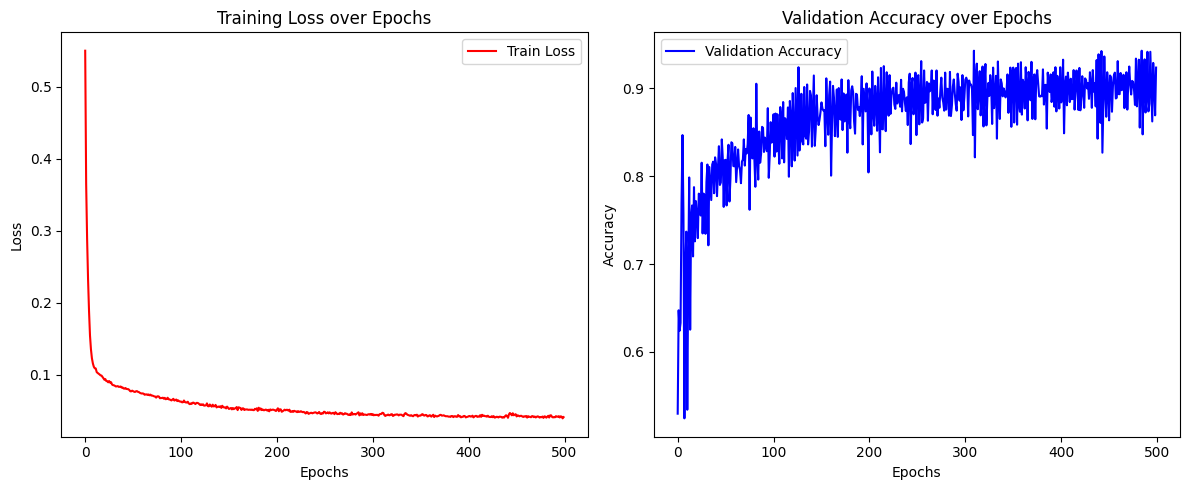

In [53]:
# Plot Training Loss and Validation Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='red')
plt.title('Training Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_accs, label='Validation Accuracy', color='blue')
plt.title('Validation Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## Step 3: Evaluation and Confusion Matrix
Finally, we evaluate the model strictly on the 15% hidden test set and output the classification metrics.


Test Accuracy: 0.9220

Classification Report on Test Set:
                     precision    recall  f1-score   support

         Normal (0)       0.96      0.95      0.96      2141
       Spoofing (1)       0.45      0.53      0.49       169
Data Alteration (2)       1.00      1.00      1.00       138

           accuracy                           0.92      2448
          macro avg       0.80      0.83      0.81      2448
       weighted avg       0.93      0.92      0.93      2448



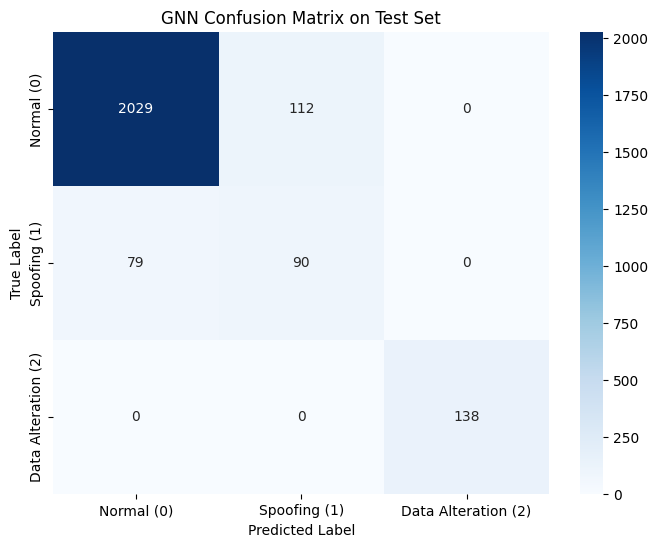

In [54]:
# Evaluate purely on Test Set
test_acc = evaluate(data.test_mask)
print(f'Test Accuracy: {test_acc:.4f}\n')

# Get predictions for the test mask
model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)

test_preds = pred[data.test_mask].numpy()
test_true = data.y[data.test_mask].numpy()

target_names = ['Normal (0)', 'Spoofing (1)', 'Data Alteration (2)']
print("Classification Report on Test Set:")
print(classification_report(test_true, test_preds, target_names=target_names))

# Plot Confusion Matrix
cm = confusion_matrix(test_true, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('GNN Confusion Matrix on Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()